# env설정

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

True

In [3]:
os.getenv("OPENAI_API_KEY")
default_model = os.getenv("OPENAI_DEFAULT_MODEL")
print(default_model)

from openai import OpenAI

client = OpenAI()

gpt-4o-mini


# 문맥 기억하기 
- system-user-assistant-user-assistant-..

### 문제 : LLM은 기본적으로 이전 대화를 기억하지 못한다.

In [ ]:
while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    if input_message.lower() == "quit":
        print("프로그램을 종료합니다.")
        break

    ret = client.responses.create(
        model=default_model,
        instructions="너는 친절한 가이드야.",
        input=[{"role":"user", "content": input_message}]
    )
    print(ret.output[0].content[0].text)
    print('='*100)
    

프로그램을 종료합니다.


### 해결 : 맥락을 이해하도록 만들기

In [89]:
message=[]

while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    if input_message.lower() == "quit":
        print("프로그램을 종료합니다.")
        break
    # 이전 대화 내용과 함께 새로운 질문을 추가하여 모델에 전달
    message.append({"role":"user", "content": input_message})

    ret = client.responses.create(
        model = default_model,
        instructions = "너는 친절한 가이드야.",
        input = message
    )
    # 모델의 응답을 대화 기록에 추가
    message.append({"role":"assistant", "content": ret.output[0].content[0].text})

    print(ret.output[0].content[0].text)
    print('='*100)
    

프로그램을 종료합니다.


In [90]:
# 메세지 확인해보기
message

[]

In [91]:
import tiktoken

default_model = "gpt-4o-mini"

text = (
    "줄바꿈 없이 숫자를 콤마(,)로 구분하고 "
    "1부터 100까지 숫자를 세줘. 예를 들면 : 1, 2, 3, ...."
)

print("원본 문자열 : ", text)

encoding = tiktoken.encoding_for_model(default_model)
tokens = encoding.encode(text)

print(f"토큰 개수: {len(tokens)}")
print(f"토큰 목록: {tokens}")
print()

models = [
    "gpt-4o-mini",
    "gpt-4-turbo",
    "gpt-3.5-turbo"
]

for model in models:
    try:
        encoding = tiktoken.encoding_for_model(model)
        tokens = encoding.encode(text)

        print(f"[{model}]")
        print(f"토큰 수: {len(tokens)}")
        print(f"처음 10개 토큰: {tokens[:10]}")
        print(f"복원 결과: {encoding.decode(tokens[:10])}")
        print("-" * 50)

    except Exception as e:
        print(f"{model} 오류")
        print(e)

원본 문자열 :  줄바꿈 없이 숫자를 콤마(,)로 구분하고 1부터 100까지 숫자를 세줘. 예를 들면 : 1, 2, 3, ....
토큰 개수: 41
토큰 목록: [78167, 16648, 164836, 111626, 151353, 89174, 79316, 97, 11630, 7, 83132, 3710, 23019, 15567, 17231, 220, 16, 42070, 220, 1353, 37046, 151353, 89174, 28126, 153545, 13, 28065, 4831, 37386, 9018, 712, 220, 16, 11, 220, 17, 11, 220, 18, 11, 23635]

[gpt-4o-mini]
토큰 수: 41
처음 10개 토큰: [78167, 16648, 164836, 111626, 151353, 89174, 79316, 97, 11630, 7]
복원 결과: 줄바꿈 없이 숫자를 콤마(
--------------------------------------------------
[gpt-4-turbo]
토큰 수: 57
처음 10개 토큰: [59269, 226, 39277, 242, 166, 123, 230, 47782, 13094, 70292]
복원 결과: 줄바꿈 없이 �
--------------------------------------------------
[gpt-3.5-turbo]
토큰 수: 57
처음 10개 토큰: [59269, 226, 39277, 242, 166, 123, 230, 47782, 13094, 70292]
복원 결과: 줄바꿈 없이 �
--------------------------------------------------


# 실시간 정보 알기!-tools

In [92]:
""" 사용자 질문
   ↓
[1차 호출] 모델: "get_weather(city='부산') 실행해줘"  ← 답이 아니라 주문서
   ↓
[우리 코드] 실제로 함수 실행 → "흐림 22도"
   ↓
[2차 호출] 질문+주문서+결과를 모델에 전달
   ↓
모델: "부산의 오늘 날씨는 흐림, 22도예요!"  ← 최종 자연어 답변 """

' 사용자 질문\n   ↓\n[1차 호출] 모델: "get_weather(city=\'부산\') 실행해줘"  ← 답이 아니라 주문서\n   ↓\n[우리 코드] 실제로 함수 실행 → "흐림 22도"\n   ↓\n[2차 호출] 질문+주문서+결과를 모델에 전달\n   ↓\n모델: "부산의 오늘 날씨는 흐림, 22도예요!"  ← 최종 자연어 답변 '

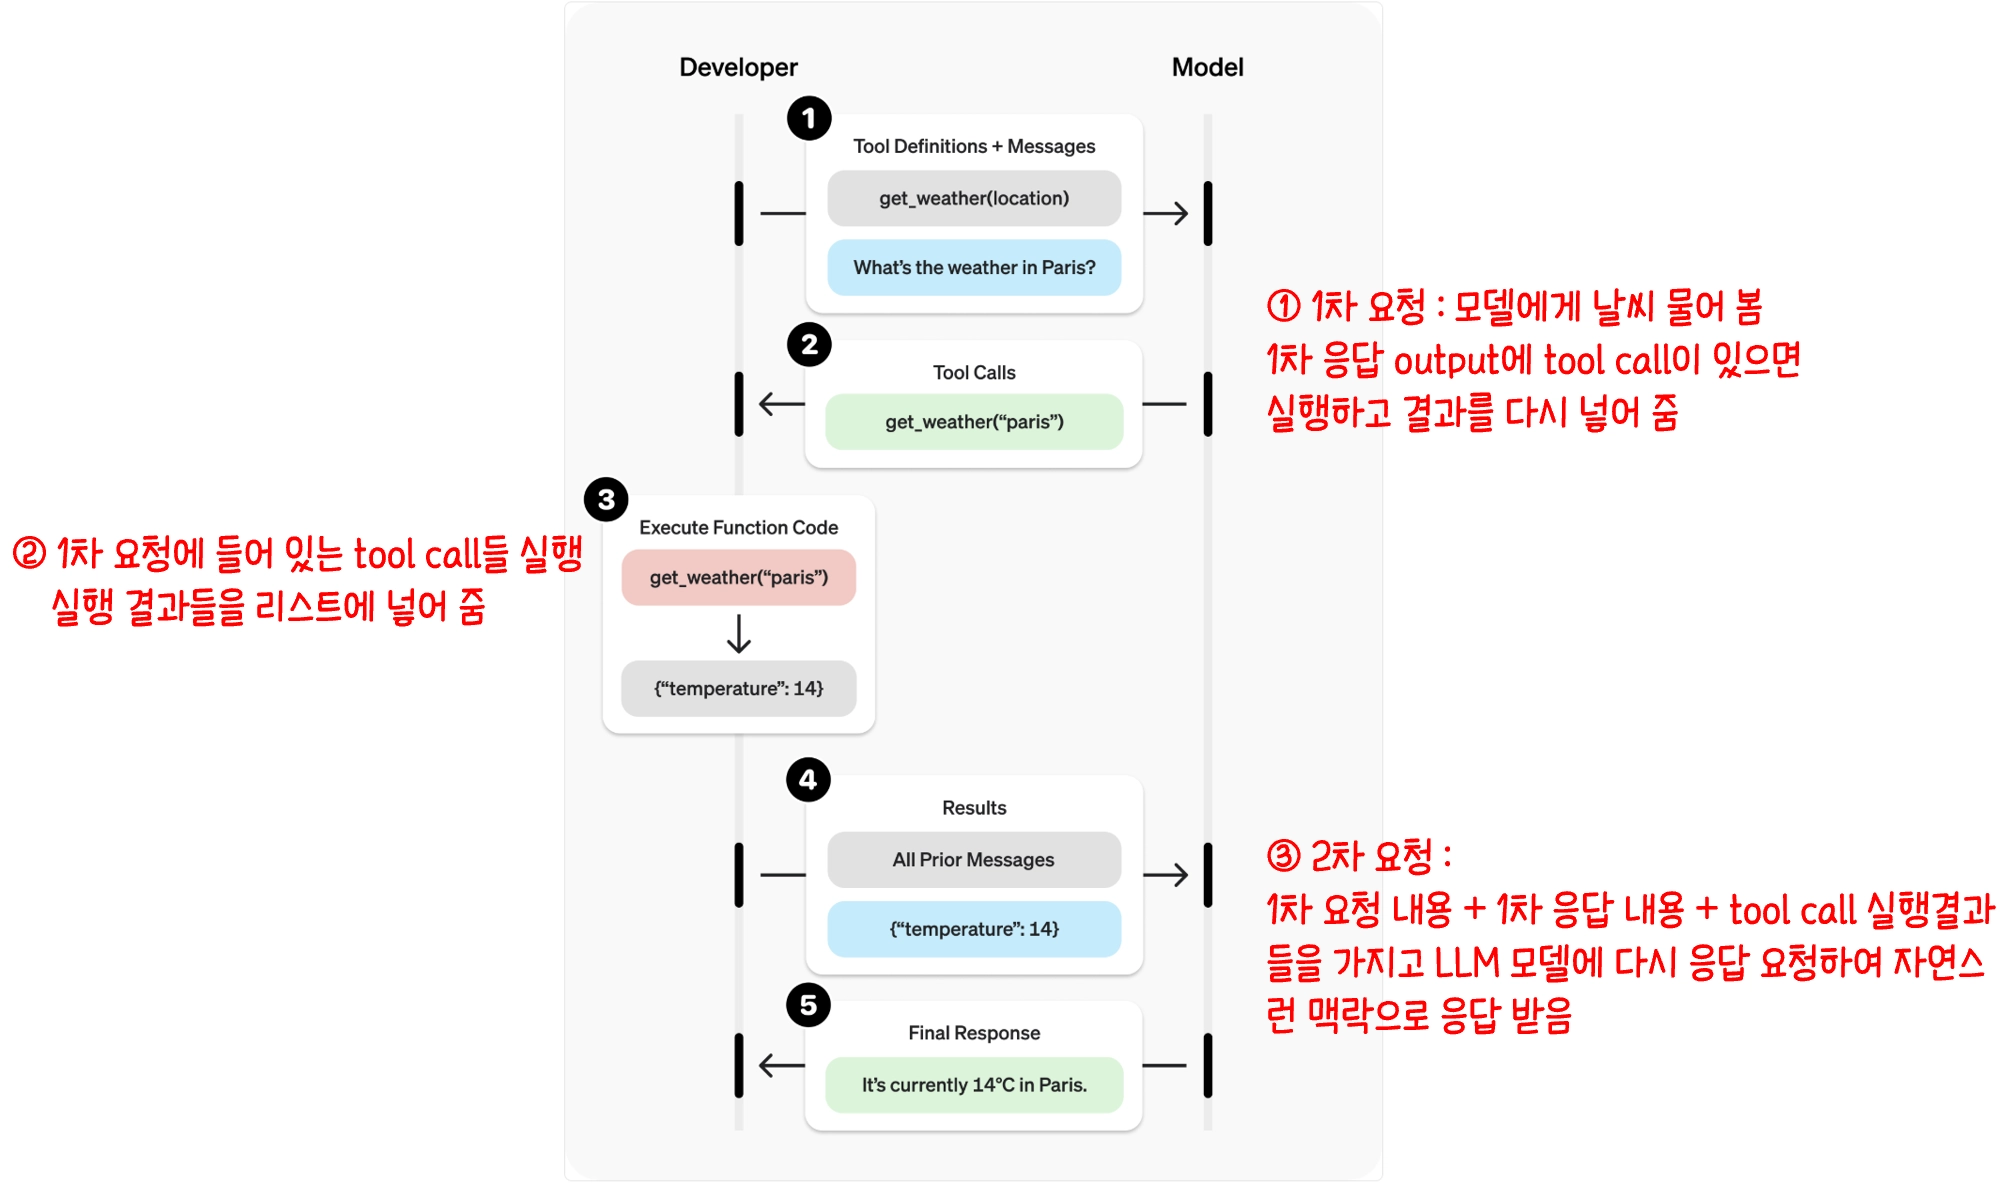

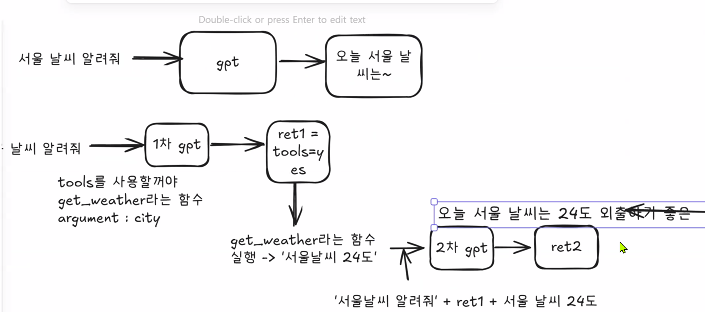

### tools 적용 전

In [93]:
city = "서울"

response = client.responses.create(
    model = default_model,
    input = [{'role':'user',
              'content':f'오늘 {city} 날씨 알려줘!'}],
    temperature=0
)

print(f'응답 데이터 : {response.output[0].content[0].text}')

응답 데이터 : 죄송하지만, 현재 실시간 날씨 정보를 제공할 수는 없습니다. 서울의 날씨를 확인하려면 기상청 웹사이트나 날씨 앱을 이용해 보세요! 도움이 필요하시면 다른 질문 해주세요.


### tools 적용 후

In [94]:
# 함수 정의
import datetime


def get_weather(city):
    """도시 이름을 입력 받아서 해당 도시의 날씨를 반환하는 함수"""
    weather_data = {'서울':'맑음 24도',
                    '부산':'흐림 22도',
                    '울산':'비옴 20도',
                    '도쿄':'맑음 25도'}
    # dictionary 에서 get은 key를 읽어옴:(도시들),없으면 ''문구 출력하는 것
    return weather_data.get(city,'해당 도시의 날씨를 찾을 수 없습니다.')

def get_time(timezone: str = "Asia/Seoul") -> str:
    """실시간을 반환하는 함수"""
    # (예시) 실제 timezone 변환은 생략하고 문자열로만 표시
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    return f"{timezone} 기준 현재 시간: {current_time}"

def search_info(query: str) -> str:
    """해당 객체에 대한 설명을 해주는 함수"""
    info_data = {
        "파이썬": "파이썬은 1991년 귀도 반 로섬이 개발한 프로그래밍 언어입니다.",
        "AI": "인공지능(AI)은 기계가 인간의 지능을 모방하는 기술입니다.",
        "서울": "서울은 대한민국의 수도이며 약 950만 명이 거주합니다.",
        "박혜준":"키움디지털 아카데미를 열심히 듣고있는 학생입니당!"
    }
    return info_data.get(query, f"'{query}'에 대한 정보를 찾을 수 없습니다.")

def calculate(operation: str, a: float, b: float) -> str:
    """계산값을 반환하는 함수"""
    if operation == "add":
        return f"{a} + {b} = {a + b}"
    elif operation == "subtract":
        return f"{a} - {b} = {a - b}"
    elif operation == "multiply":
        return f"{a} × {b} = {a * b}"
    elif operation == "divide":
        if b != 0:
            return f"{a} ÷ {b} = {a / b}"
        return "0으로 나눌 수 없습니다."
    return "지원하지 않는 연산입니다."



In [95]:
# doc_string나오는 거 확인
help(get_weather)
help(get_time)
help(search_info)
help(calculate)

Help on function get_weather in module __main__:

get_weather(city)
    도시 이름을 입력 받아서 해당 도시의 날씨를 반환하는 함수

Help on function get_time in module __main__:

get_time(timezone: str = 'Asia/Seoul') -> str
    실시간을 반환하는 함수

Help on function search_info in module __main__:

search_info(query: str) -> str
    해당 객체에 대한 설명을 해주는 함수

Help on function calculate in module __main__:

calculate(operation: str, a: float, b: float) -> str
    계산값을 반환하는 함수



### tools의 속성 설정하기

- 함수 이름, 매개변수, 필수 여부등 (tools가 여러 개이면 여러 개의 설정하기가 필요함)

In [ ]:
tools = [
    {
        "type": "function",
        "name": "get_weather",
        "description": "도시 이름을 입력 받아서 해당 도시의 날씨를 반환하는 함수",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "날씨를 알고 싶은 도시 이름"
                },
            },
            "required": ["city"]
        }
    },
    {
        # get_time(timezone: str = 'Asia/Seoul') -> str
        "type": "function",
        "name": "get_time",
        "description": "실시간을 반환하는 함수",
        "parameters": {
            "type": "object",
            "properties": {
                "timezone": {
                    "type": "integer",
                    "description": "실시간"
                },
            }
        }
    },
    {
        # search_info(query: str) -> str
        "type": "function",
        "name": "search_info",
        "description": "해당 객체에 대한 설명을 해주는 함수",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "설명을 듣고싶은 객체"
                },
            },
            "required": ["query"]
        }
    },
    {
        # calculate(operation: str, a: float, b: float) -> str
        "type": "function",
        "name": "calculate",
        "description": "계산값을 반환하는 함수",
        "parameters": {
            "type": "object",
            "properties": {
                "operation": {
                    "type": "string",
                    "enum": ["add", "subtract", "multiply", "divide"],
                    "description": "수행할 연산 종류 (add, subtract, multiply, divide)"
                },
                "a": {
                    "type": "number",
                    "description": "첫 번째 숫자 (피연산자 A)"
                },
                "b": {
                    "type": "number",
                    "description": "두 번째 숫자 (피연산자 B)"
                }
            },
            "required": ["operation", "a", "b"]
        }
    }
]

### 사용 가능한 tools 목록을 만든다

- LLM은 “get_weather”라는 **문자열 이름**만 생성
- 실제 실행은 Python함수가 함
- 그래서 **함수 이름 → 실제 함수 객체**를 연결해주는 딕셔너리가 필요한데,
이 딕셔너리는 모델이 호출한 함수 이름을 실제 파이썬 함수와 연결하는 역할을 한다.

In [97]:
# 사용 가능한 함수들을 딕셔너리로 매핑
tool_map = {"get_weather":get_weather,
            "get_time":get_time,
            "search_info":search_info,
            "calculate":calculate}


# tools 여러개 사용 가능 get_time,..등등 : tools에 추가로 적어주면 됨.
# tool_map = {"get_weather":get_weather,'get_time':get_time}

### 응답 메세지에서 tool_calls가 감지되면

- LLM이 function_call을 생성하면,
    
    시스템이 tool_map을 통해 해당 함수를 실행하고, 그 결과를 다시 LLM에 전달하여 최종 답변을 만듦

In [98]:
city = '부산'
input_msg = [{'role':'user','content':f'{city}의 오늘 날씨를 알려줘'}]

ret1 = client.responses.create(
    model = default_model,
    input = input_msg,
    tools = tools,
    # 오늘 날씨와 가장 의미적으로 맥락이 맞는 아이를 검색해서 네가 알아서 자동으로 실행해!
    tool_choice = "auto"
)
# print(ret1) ;print(ret1.output)

In [99]:
import json

#================================ 1차 호출
# tool의 결과와 gpt ret1의 결과를 같이 봐야하니까 리스트로 저장
tool_output = []

for item in ret1.output:
    if item.type == 'function_call':
        func_name = item.name 
        arguments = json.loads(item.arguments or '{}')

        result = tool_map[func_name](**arguments) 
        tool_output.append({
            'type':'function_call_output',
            'call_id' : item.call_id,
            'output': result
        })

# 결과 확인
print(result)

call_id='call_k2QzqX491YSXfEa3YaaNoTdm'
arguments='{"city":"부산"}'
name='get_weather'
type='function_call'

#================================ 2차 호출
# 함수 실행 결과를 모델에 다시 전달
if tool_output:                     # tool이 호출된 경우
    ret2 = client.responses.create( # 2차 요청: 함수 실행 결과를 모델에 다시 전달
        model = default_model,
        input = input_msg + ret1.output + tool_output
        # 원래 입력 + 1차 모델 출력 + 함수 실행 결과를 함께 전달
        # 이렇게 해야 모델이 최종 자연어 답변을 생성할 수 있음 
    ) 
    print(ret2.output_text)    # 최종 자연어 응답 출력
else:
    print(ret1.output_text)    # tool call 없이 바로 답변이 나온 케이스


흐림 22도
부산의 오늘 날씨는 흐리고, 기온은 22도입니다. 외출 시 우산 챙기시는 것이 좋겠어요!


### 내가 해보기 01
- search_info()

In [100]:
info_data = '박혜준'
input_msg = [{'role':'user','content':f'{info_data}에 대해서 알려줘!'}]

ret11 = client.responses.create(
    model = default_model,
    input = input_msg,
    tools = tools,
    tool_choice = "auto"
)
print(ret11) ;print(ret11.output)

Response(id='resp_0bb42ed09f11e2a7006a30d3943bd48199a73e6b2a924a2939', created_at=1781584788.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4o-mini-2024-07-18', object='response', output=[ResponseFunctionToolCall(arguments='{"query":"박혜준"}', call_id='call_nTWQzuP4mYeClSyg1YBhMurv', name='search_info', type='function_call', id='fc_0bb42ed09f11e2a7006a30d39505188199855176aff5f56728', namespace=None, status='completed')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[FunctionTool(name='get_weather', parameters={'type': 'object', 'properties': {'city': {'type': 'string', 'description': '날씨를 알고 싶은 도시 이름'}}, 'required': ['city'], 'additionalProperties': False}, strict=True, type='function', defer_loading=None, description='도시 이름을 입력 받아서 해당 도시의 날씨를 반환하는 함수'), FunctionTool(name='get_time', parameters={'type': 'object', 'properties': {'current_time': {'type': 'integer', 'description': '실시간'}}, 'additionalProperties': False, 'required':

In [101]:
import json

arguments='{"object":"박혜준"}'
call_id='call_snkkCWU5r0Pap3PYRTxC4HRG'
name='search_info'
type='function_call'

#================================ 1차 호출
# tool의 결과와 gpt ret1의 결과를 같이 봐야하니까 리스트로 저장
import json

tool_output = []

for item in ret11.output:
    if item.type == 'function_call':
        func_name = item.name
        arguments = json.loads(item.arguments or '{}')

        result = tool_map[func_name](**arguments)

        tool_output.append({
            'type': 'function_call_output',
            'call_id': item.call_id,
            'output': result
        })

print(result)

if tool_output:
    ret22 = client.responses.create(
        model=default_model,
        input=input_msg + ret11.output + tool_output
    )
    print(ret22.output_text)
else:
    print(ret11.output_text)

키움디지털 아카데미를 열심히 듣고있는 학생입니당!
박혜준은 키움디지털 아카데미의 학생으로, 디지털 관련 교육을 열심히 받고 있는 모습입니다. 키움디지털 아카데미는 다양한 디지털 기술과 지식을 습득할 수 있는 프로그램으로, 최신 트렌드와 실무적인 기술을 배울 수 있는 좋은 기회입니다. 어떤 분야에 관심이 있는지 더 알고 싶으신가요?


### 내가 해보기 02
- calculate()

In [102]:
operation = 'multiply'
a = '5' 
b = '7'

input_msg = [{'role':'user','content':f'{a} {operation} {b}의 값을 알려줘!'}]

ret111 = client.responses.create(
    model = default_model,
    input = input_msg,
    tools = tools,
    tool_choice = "auto"
)
print(ret111) ;print(ret111.output)

Response(id='resp_0eb9205acec25bf4006a30d3987fbc8199835e195a1fa55f3d', created_at=1781584792.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4o-mini-2024-07-18', object='response', output=[ResponseFunctionToolCall(arguments='{"operation":"multiply","a":5,"b":7}', call_id='call_JEZDX19NQ6fYj6HSZgsDRZac', name='calculate', type='function_call', id='fc_0eb9205acec25bf4006a30d3992bc48199a6de97de75d145bc', namespace=None, status='completed')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[FunctionTool(name='get_weather', parameters={'type': 'object', 'properties': {'city': {'type': 'string', 'description': '날씨를 알고 싶은 도시 이름'}}, 'required': ['city'], 'additionalProperties': False}, strict=True, type='function', defer_loading=None, description='도시 이름을 입력 받아서 해당 도시의 날씨를 반환하는 함수'), FunctionTool(name='get_time', parameters={'type': 'object', 'properties': {'current_time': {'type': 'integer', 'description': '실시간'}}, 'additionalProperties':

In [103]:
import json

#================================ 1차 호출
# tool의 결과와 gpt ret1의 결과를 같이 봐야하니까 리스트로 저장
import json

tool_output = []

for item in ret111.output:
    if item.type == 'function_call':
        func_name = item.name
        arguments = json.loads(item.arguments or '{}')

        result = tool_map[func_name](**arguments)

        tool_output.append({
            'type': 'function_call_output',
            'call_id': item.call_id,
            'output': result
        })

print(result)

if tool_output:
    ret222 = client.responses.create(
        model=default_model,
        input=input_msg + ret111.output + tool_output
    )
    print(ret222.output_text)
else:
    print(ret11.output_text)

5 × 7 = 35
5 multiply 7의 값은 35입니다.


## GPT + Tool

- 모델 사용 비용 + Web Search 비용으로 구성

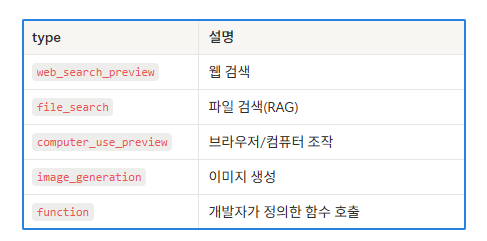

In [104]:
question = "서울 날씨 어때?"

response = client.responses.create(
    model=default_model,
    tools=[{"type": "web_search_preview"}],
    input=question
)

print(response.output_text)

현재 서울의 기온은 약 21도이며, 오늘 낮 최고 기온은 32도까지 오를 것으로 예상됩니다. 오늘 하루 맑은 날씨가 지속될 것으로 보입니다. ([news.sbs.co.kr](https://news.sbs.co.kr/news/endPage.do?news_id=N1008611087&plink=OLDURL&utm_source=openai))

내일도 맑은 날씨가 지속되며, 아침 기온은 21도, 낮 기온은 32도까지 오를 것으로 예상됩니다. ([news.sbs.co.kr](https://news.sbs.co.kr/news/endPage.do?news_id=N1008611087&plink=OLDURL&utm_source=openai))

따라서 오늘과 내일은 맑고 더운 날씨가 지속될 것으로 보입니다. 


In [105]:
# 1. Vector Store 생성
vector_store = client.vector_stores.create(
    name="PDF 저장소"
)

# 2. a.pdf 업로드 + Vector Store에 등록
file_batch = client.vector_stores.file_batches.upload_and_poll(
    vector_store_id=vector_store.id,
    files=[open("MLOps_실무_완전정복_교재.pdf", "rb")]
)

print("업로드 상태:", file_batch.status)
print("파일 개수:", file_batch.file_counts)

# 3. File Search로 PDF 검색/요약
response = client.responses.create(
    model="gpt-4o-mini",
    tools=[{
            "type": "file_search",
            "vector_store_ids": [vector_store.id]
        }],
    input="업로드한 PDF를 5줄로 요약해줘."
)

print(response.output_text)

업로드 상태: completed
파일 개수: FileCounts(cancelled=0, completed=1, failed=0, in_progress=0, total=1)
PDF 내용을 다섯 줄로 요약하자면:

1. 이 교재는 MLOps(머신러닝 운영)를 통해 ML/AI 엔지니어가 필요한 기술 역량을 현업 중심으로 체계적으로 다룹니다.
2. 데이터 파이프라인 구축, 모델 설계, 실험 설계, A/B 테스트 등을 포함한 다양한 주제를 포괄합니다.
3. Pandas, SQL, TensorFlow, PyTorch 등 실무에서 사용되는 다양한 도구와 기법을 소개합니다.
4. CI/CD, 클라우드 환경 구축 및 API 연동 등 MLOps의 전반적인 운영 절차와 Best Practices를 제공합니다.
5. 학습 로드맵과 실습 프로젝트를 통해 실제 ML 시스템을 구축하는 데 필요한 단계별 가이드를 제시합니다.


# 제미나이

In [112]:
#환경파일에서 OpenAI API 키 불러오기
from dotenv import load_dotenv
import os

load_dotenv(override=True)
gemini_api_key = os.getenv("GEMINI_API_KEY")
gemini_default_model = os.getenv("GEMINI_DEFAULT_MODEL")
print(gemini_default_model)

gemini-2.5-flash


In [113]:
from google import genai

gclient = genai.Client()

In [114]:
for model in gclient.models.list():
    print(model)

name='models/gemini-2.5-flash' display_name='Gemini 2.5 Flash' description='Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.' version='001' endpoints=None labels=None tuned_model_info=TunedModelInfo() input_token_limit=1048576 output_token_limit=65536 supported_actions=['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent'] default_checkpoint_id=None checkpoints=None temperature=1.0 max_temperature=2.0 top_p=0.95 top_k=64 thinking=True
name='models/gemini-2.5-pro' display_name='Gemini 2.5 Pro' description='Stable release (June 17th, 2025) of Gemini 2.5 Pro' version='2.5' endpoints=None labels=None tuned_model_info=TunedModelInfo() input_token_limit=1048576 output_token_limit=65536 supported_actions=['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent'] default_checkpoint_id=None checkpoints=None temperature=1.0 max_temperature=2.0 top_p=0.95 top_k=64 thi

In [116]:
response = gclient.models.generate_content(
    model = gemini_default_model,
    contents = '사과는 무슨 색이니? 어떤 맛이고?'
)
print(response.text) 

사과는 한 가지 색이 아니에요!

1.  **무슨 색이니?**
    *   가장 흔하게 볼 수 있는 색은 **빨간색**입니다. (예: 부사, 홍옥, 갈라)
    *   하지만 **초록색** 사과도 아주 많아요. (예: 아오리 사과, 그래니 스미스)
    *   **노란색** 사과도 있답니다. (예: 골든 딜리셔스)
    *   어떤 품종은 빨간색과 노란색이 섞여 있기도 해요. 즉, **품종에 따라 색이 다양합니다.**

2.  **어떤 맛이고?**
    *   사과의 맛은 품종과 익은 정도에 따라 차이가 있지만, 일반적으로 **달콤하면서도 새콤한 맛**이 특징이에요.
    *   **아삭하고 시원한 식감**에 **과즙이 풍부**해서 먹는 재미가 있죠.
    *   **빨간 사과**들은 주로 달콤한 맛이 강하고,
    *   **초록 사과** (아오리, 그래니 스미스 등)는 새콤한 맛이 더 두드러지는 경우가 많습니다.

요약하면, 사과는 **빨강, 초록, 노랑 등 다양한 색깔**을 가지며, 맛은 **달콤새콤하고 아삭하며 즙이 많은** 것이 특징입니다!


In [121]:
response = gclient.models.generate_content(
    model = gemini_default_model,
    contents = '봄에 대해 알려줘',
    config = {'system_instruction':'너는 java개발자로 스프링 프레임워크 전문가야.',
              'temperature':0.2,
              'max_output_tokens':500}
)
print(response.text) 

아, '봄'이라 하시면 역시 저 같은 자바 개발자에게는 계절


## 차트분석 부탁하기

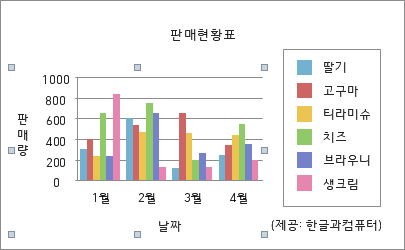

In [125]:
# 1. 이미지 파일 읽기 (바이트 데이터)
with open("C:/AI_service/4i05_chart2_plot.png", "rb") as f:
    image_data = f.read()

# 2. 멀티모달 콘텐츠 생성 (텍스트와 이미지를 리스트로 묶어서 전달)
response = gclient.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        "이 차트 결과를 한국어로 자세히 설명해줘. 긍정/부정 비율, 주요 키워드, 계약서 위험도까지 분석해줘.",
        {
            "inline_data": {
                "data": image_data, 
                "mime_type": "image/png"
            }
        },
    ],
)

# 3. 응답 출력
print(response.text)

이 차트("판매현황표")는 1월부터 4월까지의 6가지 제품(딸기, 고구마, 티라미슈, 치즈, 브라우니, 생크림)에 대한 월별 판매량을 보여주고 있습니다. 각 항목에 대해 자세히 분석해 드리겠습니다.

---

### 1. 전체 판매 현황 요약

*   **기간:** 1월 ~ 4월 (4개월)
*   **측정 지표:** 판매량 (Y축: 0~1000 단위)
*   **제품 종류:** 6가지 (딸기, 고구마, 티라미슈, 치즈, 브라우니, 생크림)
*   **전반적 추이:** 2월에 총 판매량이 가장 높았으며, 3월에 감소했다가 4월에 소폭 회복하는 경향을 보입니다. 제품별로 판매량의 변동폭과 추이가 매우 다르게 나타납니다.

---

### 2. 월별 판매 추이 (제품별)

#### 1월
*   **생크림 (약 850):** 압도적으로 가장 높은 판매량을 기록했습니다.
*   **치즈 (약 670):** 두 번째로 높은 판매량을 보였습니다.
*   **고구마 (약 420):** 중간 수준의 판매량입니다.
*   **딸기 (약 350):** 중간 수준입니다.
*   **브라우니 (약 260), 티라미슈 (약 250):** 낮은 판매량을 기록했습니다.

#### 2월
*   **치즈 (약 780):** 1월보다 더 높은 판매량으로 선두를 달렸습니다.
*   **브라우니 (약 670):** 1월 대비 크게 상승하며 높은 판매량을 기록했습니다.
*   **딸기 (약 600):** 1월 대비 크게 상승했습니다.
*   **고구마 (약 550):** 1월 대비 상승했습니다.
*   **티라미슈 (약 480):** 1월 대비 상승했습니다.
*   **생크림 (약 150):** 1월에 압도적이었던 판매량이 급격하게 폭락하여 최하위권으로 떨어졌습니다.

#### 3월
*   **고구마 (약 670):** 2월 대비 상승하며 이달의 최고 판매량을 기록했습니다.
*   **티라미슈 (약 480):** 2월과 비슷한 수준을 유지했습니다.
*   **브라우니 (약 280):** 2월 대비 

In [126]:
# 1. 이미지 파일 읽기 (바이트 데이터)
with open("C:/AI_service/marketing_chart_Example.png", "rb") as f:
    image_data = f.read()

# 2. 멀티모달 콘텐츠 생성 (텍스트와 이미지를 리스트로 묶어서 전달)
response = gclient.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        "이 차트 결과를 한국어로 자세히 설명해줘. 긍정/부정 비율, 주요 키워드, 계약서 위험도까지 분석해줘.",
        {
            "inline_data": {
                "data": image_data, 
                "mime_type": "image/png"
            }
        },
    ],
)

# 3. 응답 출력
print(response.text)

이 차트는 "주간 기준 마케팅 간트 차트"로, 12주간의 마케팅 활동 일정을 시각적으로 보여주는 프로젝트 관리 도구입니다. 현재 시점은 주황색 점선으로 표시된 '17 May'로, 전체 12주 일정 중 약 5주 차에서 6주 차 사이에 해당합니다.

차트의 범례는 다음과 같습니다:
*   **파란색 (completed):** 작업이 완료됨
*   **노란색 (To be completed):** 작업이 진행 중이거나 완료 예정임 (보통 파란색과 노란색 그라데이션은 진행 중인 상태를 나타냄)
*   **빨간색 (Not started):** 작업이 아직 시작되지 않음

---

### 차트 결과 상세 설명

#### 1. 전반적인 진행 상황 (17 May 기준)

*   **유료 미디어 광고 (Paid Media Advertising) 부문:**
    *   **Paid Social (5일):** **완료됨** (파란색).
    *   **Paid Search (5일):** **대부분 완료되었으며, 일부 진행 중** (파란색에서 노란색 그라데이션).
    *   **Display Advertising (10일):** **진행 중/완료 예정** (파란색에서 노란색 그라데이션).
    *   **Text Here (10일):** **진행 중/완료 예정** (파란색에서 노란색 그라데이션).
    *   **요약:** 유료 미디어 광고 부문은 전반적으로 순조롭게 진행되거나 상당 부분 완료된 상태입니다. 대부분의 활동이 계획대로 진행되고 있음을 알 수 있습니다.

*   **소셜 미디어 마케팅 (Social Media Marketing) 부문:**
    *   **Instagram (12일):** **시작되지 않음** (빨간색).
    *   **Facebook (4일):** **시작되지 않음** (빨간색).
    *   **Twitter (5일):** **시작되지 않음** (빨간색).
    *   **Text Here (14일):** **시작되지 않음** (빨

### mime_type

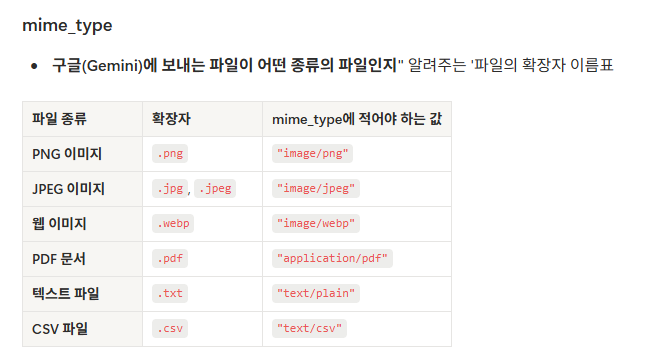

# 유투브 영상 분석

In [ ]:
https://youtu.be/IMs7Mj-fPqE?si=zkQLOhfznSvojIro

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)

os.getenv("OPENAI_API_KEY")
default_model = os.getenv("OPENAI_DEFAULT_MODEL")
print(default_model)

from openai import OpenAI
client = OpenAI()

gpt-4o-mini


## 유튜브 영상에서 음원 추출

In [3]:
import yt_dlp
from openai import OpenAI
from pydub import AudioSegment

client = OpenAI()

def download_audio(youtube_url, output_path="temp_audio.%(ext)s"):
    """유튜브에서 오디오만 다운로드"""
    ydl_opts = {
        'format': 'bestaudio/best',
        'outtmpl': output_path,
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '192',
        }],
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([youtube_url])
        info = ydl.extract_info(youtube_url, download=False)
        return ydl.prepare_filename(info).rsplit('.', 1)[0] + '.mp3'

def audio_to_text(audio_path):
    """Whisper API로 음성 → 텍스트"""
    with open(audio_path, "rb") as audio_file:
        transcript = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio_file,
            language="ko"  # 한국어 우선
        )
    return transcript.text


In [4]:
url = "https://youtu.be/IMs7Mj-fPqE?si=zkQLOhfznSvojIro"  # 여기에 URL

print("1. 유튜브 오디오 다운로드 중...")
audio_file = download_audio(url)

print("2. Whisper로 텍스트 변환 중...")
full_text= audio_to_text(audio_file)

print("\n=== 변환된 텍스트 ===")
print(full_text)

1. 유튜브 오디오 다운로드 중...
[youtube] Extracting URL: https://youtu.be/IMs7Mj-fPqE?si=zkQLOhfznSvojIro
[youtube] IMs7Mj-fPqE: Downloading webpage


[youtube] IMs7Mj-fPqE: Downloading android vr player API JSON
[info] IMs7Mj-fPqE: Downloading 1 format(s): 251
[download] temp_audio.webm has already been downloaded
[download] 100% of    6.60MiB
[ExtractAudio] Destination: temp_audio.mp3
Deleting original file temp_audio.webm (pass -k to keep)
[youtube] Extracting URL: https://youtu.be/IMs7Mj-fPqE?si=zkQLOhfznSvojIro
[youtube] IMs7Mj-fPqE: Downloading webpage


[youtube] IMs7Mj-fPqE: Downloading android vr player API JSON
2. Whisper로 텍스트 변환 중...

=== 변환된 텍스트 ===
안녕하세요. 안녕하세요! 오늘은 찐친 데유가 노말 여름휴가를 가는 날입니다. 일어나시라고요. 안녕하세요. 렛츠고! 여러분들 조심해서 와라. 가볍게 와서 왔는데 지금 사람 개많고요. 우리 이상하고요. 배가 너무 고파요. 핫도그 핫바 개쳐먹어. 핫바 말고? 우리 나눠먹자, 지영아. 뭐를? 핫바를? 아 깜짝이야. 핫바 하나로 나눠먹자 한 줄 알고 개깜짝 놀랬는데. 김치찌개! 비빔밥! 맛이 없을 것 같아. 통새우 핫바. 야야 옷에 다 떨어져. 이거 뭐야? 이거 내 거. 개맛있지? 야 생새우 아니야? 하나 둘 셋! 이거 너무 장난 아니야? 제가 방금 어떤 강아지를 봤습니다. 강아지의 똥꼬가 핑크색이었어요. 그래서 방금 영감이 떠올라서 작곡을 해봤습니다. 니 똥꼬 무슨 색이야? 니 똥꼬 무슨 색이야? 나는 검은색. 나는 검은색. 니 검은색이야. 니 똥꼬 무슨 색이야? 나 하얀색. 어때요? 제목은 니 똥색. 자 이제 카페로 가보도록 하겠습니다. 땡큐. 아 미친 여기 사우나 아니야? 아 진짜 내 하얀 똥꼬 껌해지겠는데. 안녕하세요. 안녕하세요! 여러분 저는 사실 대머리에요! 아 진짜 무서워. 진짜 무서워. 빨리 빨리 빨리. 눈이 너무 부시잖아 야! 당신이 왜 지치신 거예요? You got that fire 내 머릿속에 고통 안경 좀 내려서 써주시겠어? 여보. 길가에서 마주치면 안 되는 유형 1위. 아니 왜 이렇게 올렸으냐라고. 잣으로 1행시 해보겠습니다. 잣. 까세요. 여기 싸인 단체 아니야? 리얼? 탕탕 후루후루. 놀러 가려면 장을 봐야겠다. 어제 찍고 있었는데. 땡큐. 재밌게 놀아요 언니. 가랑이를 만나다. 어깨수가 없다. 어깨수가 없다고? 그럴 리가리가. 여기 숨어있었잖아. 여기 화장실 있는 거 있어. 아 목이 너무 마르다. 물 마셔야지. 자유자재로. I'm thirsty. 야 젊다. 여

### System 프롬프트를 이용하여 분석 내용 정하기

#### 요약, 핵심 포인트, 액션 아이템, 감성분석을 위한 프롬프트 작성

- 유튜브 영상 요약 - summary_prompt
- 유튜브 영상의 키포인트 - key_points_prompt
- 유튜브 영상 액션 아이템 - action_items_prompt
- 유튜브 영상 감성 분석 - sentiment_prompt

In [5]:
summary_prompt = """당신은 언어 이해 및 요약에 훈련된 고도로 숙련된 AI입니다.
다음 텍스트를 읽고 간결한 추상적 단락으로 요약했으면 합니다.
전체 텍스트를 읽을 필요 없이 토론의 요점을 이해하는 데 도움이 될 수 있는 일관되고
읽을 수 있는 요약을 제공하여 가장 중요한 요점을 유지하는 것을 목표로 합니다.
불필요한 세부 사항이나 접선 사항은 피하십시오."""

key_points_prompt = """당신은 정보를 핵심 포인트로 전달하는 데 특화된 능숙한 AI입니다.
다음 텍스트를 기반으로 논의되거나 언급된 주요 포인트를 확인하고 나열합니다.
이는 논의의 본질에 가장 중요한 아이디어, 결과 또는 주제가 되어야 합니다.
당신의 목표는 누군가가 읽을 수 있는 목록을 제공하여 이야기된 내용을 빠르게 이해하는 것입니다."""

action_items_prompt = """당신은 대화를 분석하고 행동 항목을 추출하는 데 있어 AI 전문가입니다.
본문을 검토하고 합의되거나 수행이 필요하다고 언급된 모든 작업, 과제 또는 행동을 식별하십시오.
이것들은 특정 개인에게 할당된 작업일 수도 있고 그룹이 취하기로 결정한 일반적인 행동일 수도 있습니다.
이러한 행동 항목을 명확하고 간결하게 나열하십시오."""

sentiment_prompt = """당신은 언어와 감정 분석에 전문성을 갖춘 AI로서 당신의 과제는 다음 텍스트의 감정을 분석하는 것입니다.
토론의 전체적인 톤, 사용된 언어가 전달하는 감정, 단어와 구가 사용되는 맥락을 고려하십시오.
감정이 일반적으로 긍정적인지 부정적인지 중립적인지를 표시하고 가능한 한 당신의 분석에 대해 간략한 설명을 제공하십시오."""

In [8]:
def text_extract(text,prompt):
    response = client.responses.create(
        model = default_model,
        input = [{'role':'system','content':prompt},
                 {'role':'user','content':text}]
    )
    return response.output_text

In [13]:
# 요약
summary = text_extract(full_text,summary_prompt)
print(summary)
print('-'*70)
key_point = text_extract(full_text,key_points_prompt)
print(key_point)
print('-'*70)
action_items = text_extract(full_text,action_items_prompt)
print(action_items)
print('-'*70)
sentiment = text_extract(full_text,sentiment_prompt)
print(sentiment)
print('-'*70)

친구들이 여름휴가를 떠나는 날, 가벼운 마음으로 만남을 시작했습니다. 사람들이 많아 핫도그와 핫바를 나누어 먹으며 소소한 유머를 나누었습니다. 강아지의 재미있는 관찰에서 영감을 얻어 즉흥 곡을 작곡하기도 했고, 카페와 수영장으로 이동하는 과정에서도 즐거운 대화를 이어갔습니다. 여러 가지 익살스러운 상황이 벌어졌고, 자잘한 게임과 웃음이 가득한 하루가 될 것임을 암시했습니다.
----------------------------------------------------------------------
주요 포인트 목록:

1. **여름휴가 계획**: 찐친들과의 여름휴가를 가는 날.
2. **음식 이야기**: 핫도그와 핫바 나눠먹기, 김치찌개와 비빔밥 언급.
3. **강아지 관찰**: 핑크색 똥꼬 강아지 보고 작곡.
4. **유머**: "니 똥꼬 무슨 색이야?"라는 재미있는 노래.
5. **카페 방문**: 카페로 가기 전에 다양한 대화.
6. **눈부심 언급**: 강한 햇빛에 대한 반응.
7. **물놀이 계획**: 수영 시간과 물놀이 게임 제안.
8. **재미있는 게임**: '물개걸'과 가랑이 사이에 공 끼우기 대결.
9. **장소 탐색**: 화장실과 물 마실 곳 탐색.
10. **유쾌한 분위기**: 친구들과 즐거운 대화와 웃음.
----------------------------------------------------------------------
1. **여행 준비**: 찐친 데유가 여름휴가를 떠나는 것임을 언급.
2. **음식 나누기**: 핫바를 나눠먹기로 결정.
3. **작곡**: 강아지의 똥꼬 색깔에 관한 노래를 작사.
4. **카페 이동**: 카페로 가기로 결정.
5. **물 마시기**: 목이 마르다며 물을 마시고 싶다는 언급.
6. **수영 계획**: 수영 시간(10시)을 정하기로 함.
7. **경기 진행**: 물개 걸이 게임을 하기로 결정. 

이러한 행동 아이템들은 그룹의 계획과 유대감을 드러냄.
-------------------------

### 전체 대화 더하기

In [27]:
new_data = {
    'summary':summary,
    'key_point':key_point,
    'action_items':action_items,
    'sentiment':sentiment
}

In [ ]:
from docx import Document
from docx.oxml.ns import qn

# 한글 폰트를 위해 사용자 정의 함수
def set_font_korean(run, font_name="Malgun Gothic"):
    run.font.name = font_name
    run._element.rPr.rFonts.set(qn("w:eastAsia"), font_name)


doc = Document()

for key, value in new_data.items():
    heading_text = " ".join(word.capitalize() for word in key.split("_"))

    heading = doc.add_heading(level=1)
    heading_run = heading.add_run(heading_text)
    set_font_korean(heading_run)

    paragraph = doc.add_paragraph()
    paragraph_run = paragraph.add_run(value)
    set_font_korean(paragraph_run)

    doc.add_paragraph()  # 빈 줄 추가

doc.save("test.docx")


# 챗봇 만들기

- gradio : 머신러닝 모델 데모 전체를 위한 프레임워크
- streamlit : 범용 데이터 대시보드 + 챗봇형
- Chainlit : 오직 LLM과 챗봇 어플리케이션만을 위해 태어난 프레임워크 / 챗봇 전문 특화형

1. Chainlit (체인릿) — 챗봇 전문 특화형
Gradio가 머신러닝 모델 데모 전체를 위한 프레임워크라면, Chainlit은 오직 LLM과 챗봇 어플리케이션만을 위해 태어난 프레임워크입니다. 이름의 'bladio'와 발음이 가장 유사하기도 합니다.
- UI 특징: ChatGPT나 Claude와 거의 흡사한 세련되고 깔끔한 챗봇 화면을 기본 제공합니다.
- 장점: * 랭체인(LangChain), 라마인덱스(LlamaIndex) 등 LLM 툴킷과 연동이 매우 쉽습니다.
- 챗봇이 답변을 생성하는 중간 과정(생각하는 단계, 툴 사용 내역)을 화면에 트리 구조로 이쁘게 시각화해 줍니다.
- 파일 업로드, 음성 입력, 데이터 요약 창 등이 기본 탑재되어 있습니다.

2. Streamlit (스트림릿) — 범용 데이터 대시보드 + 챗봇형
현재 파이썬 데이터 과학 진영에서 가장 인기가 많은 웹 대시보드 툴입니다.
- UI 특징: 왼쪽 사이드바와 메인 화면으로 구성된 깔끔한 웹 앱 형태입니다. st.chat_message 기능이 추가된 이후 챗봇 개발용으로도 엄청나게 쓰입니다.
- 장점: * 챗봇 기능뿐만 아니라 그래프(Plotly, Seaborn), 테이블, 지도 등 다양한 데이터 시각화 컴포넌트를 자유롭게 배치할 수 있습니다.
- 일반 웹사이트를 만드는 것처럼 위에서 아래로 코드가 흐르는 구조라 직관적입니다.

3. Gradio (그라디오) — 입력/출력 컴포넌트 중심형
- UI 특징: 왼쪽 입력창, 오른쪽 출력창 구조(또는 탭 구조)가 직관적이며, gr.ChatInterface를 쓰면 몇 줄 만에 챗봇 화면이 뚝딱 만들어집니다.
- 장점: Hugging Face 공간(Spaces)과 연동이 극대화되어 있어서 배포가 매우 쉽고, 이미지/오디오/비디오 등 멀티모달 입출력을 다루기에 매우 직관적입니다.

In [8]:
response = client.responses.create(
    model= default_model,
    input = [{'role':'system','content':'주어진 텍스트를 이모지로 변환하세요. 일반 텍스트를 사용하면 안되고ㅡ 반드시 이모지만 사용하세요!'},
             {'role':'user','content':'집가서 그냥 자고싶다!!'}]
)
print(response.output_text)

🏠➡️😴💤


# 그라디오(GRADIO)

In [9]:
import gradio as gr

def func(name):
    return f'Hello,{name}!'
    
demo = gr.Interface(fn = func,
            inputs='text',
            outputs='text')

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [10]:
demo.close()

Closing server running on port: 7860


In [11]:
import gradio as gr

def greet(name,is_morning,price):
    greeting = '좋은 아침입니다!' if is_morning else '좋은 저녁입니다!'
    greeting += f'{name}님!'
    return greeting, price* 3


demo = gr.Interface(
    fn=greet,
    inputs=['text','checkbox',gr.Slider(0,100)],
    outputs=['text','number']) 

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [12]:
demo.close()

Closing server running on port: 7860


In [ ]:
tab1 = gr.Interface(lambda x : x[::-1], inputs='text',outputs='text',title='뒤집기')
tab2 = gr.Interface(lambda x : x.upper(), inputs='text',outputs='text',title='대문자')

demo = gr.TabbedInterface([tab1,tab2],['뒤집기','대문자'])
demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [15]:
demo.close()

Closing server running on port: 7860


# 간단한 ChatBot 만들기

In [ ]:
import gradio as gr
import random
import time

# 응답 생성 함수
def respond(msg, chat_history):
    # 미리 정해진 문장 중 하나를 랜덤 선택
    response = random.choice(['안녕하세요', '반갑습니다', '무엇을 도와드릴까요?'])

    # 유저 메시지 먼저 히스토리에 추가
    chat_history = chat_history + [{"role": "user", "content": msg}]

    # # 응답(assistant)를 한 글자씩 조금씩 출력 (스트리밍 효과)
    stream = ""
    for ch in response:
        stream += ch 
        time.sleep(0.05)    # 출력 속도 조절을 위한 지연
        # 현재까지의 대화 내역과 사용자의 입력을 반환
        # yield를 사용해 부분 출력으로 스트리밍 구현
        yield chat_history + [{"role": "assistant", "content": stream}], ""

# Gradio Blocks UI 생성
with gr.Blocks() as bl:
    chatbot = gr.Chatbot()  # 대화 내용을 보여주는 컴포넌트 생성
    msg = gr.Textbox(placeholder="메세지를 입력하세요...", label="입력") 
    clear_btn = gr.Button("초기화")# 대화창 초기화 버튼

    # 사용자가 메시지 입력 후 엔터를 누르면 respond 함수 실행
    # 입력: msg(Textbox), chatbot(Chatbot)
    # 출력: chatbot, msg (출력은 다시 텍스트박스로 전달해 입력란 비움)
    msg.submit(respond, inputs=[msg, chatbot], outputs=[chatbot, msg])

    # 초기화 버튼 클릭 시 chatbot의 내용을 빈 리스트로 초기화
    clear_btn.click(lambda: ([], ""), inputs=None, outputs=[chatbot, msg])

# 비동기 요청 처리 대기열 활성화 yield를 사용
bl.queue().launch(share=True)

# 앱 실행 및 외부 접속 가능하도록 공유 URL 생성


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://daabe0d0d0d60cdcc1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [17]:
demo.close()

# Gradio + OpenAI API를 사용한 챗봇 만들기

In [ ]:
#OpenAI API를 사용한 스트리밍 챗봇 예제
import gradio as gr
from openai import OpenAI

client = OpenAI()

def respond(msg, chat_history):
    #1. message와 history를 OPenAI API에 맞는 포맷으로 변환
    messages = [{"role":"system", "content":"당신은 친절한 AI 챗봇입니다."}]    

    for chat in chat_history:
        if isinstance(chat, dict) and "role" in chat:
            messages.append(chat)
    messages.append({"role": "user", "content": msg})        
    
    # chat_history = chat_history or []
    full_response = ""
    updated_history = chat_history + [{"role": "user", "content": msg}]
    
    # 올바른 OpenAI API 호출
    #response는 list가 아니라 generator iterator, 한 번 순회하면 내부 상태가 끝까지 소비되고 없어짐짐
    stream = client.chat.completions.create(
        model=default_model,
        messages=messages,
        stream=True,       # 스트리밍 모드 활성화
        max_tokens=500,
        temperature=0.5    # 응답의 다양성을 조절하는 온도 파라미터
    )
    
    for chunk in stream:
        # OpenAI 스트리밍 응답 처리
        if chunk.choices[0].delta.content is not None:
            full_response += chunk.choices[0].delta.content
            yield updated_history + [{"role": "assistant", "content": full_response}], ""
    
    yield updated_history + [{"role": "assistant", "content": full_response}], ""

with gr.Blocks() as bl:
    chatbot = gr.Chatbot()  # type 제거 (Gradio 6.5.1)
    msg = gr.Textbox(placeholder="메세지를 입력하세요...", label="입력")
    clear_btn = gr.Button("초기화")

    msg.submit(respond, inputs=[msg, chatbot], outputs=[chatbot, msg])
    clear_btn.click(lambda: ([], ""), outputs=[chatbot, msg])

bl.queue().launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://34faf48bab1cdbc4df.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\AI_service\.venv\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\AI_service\.venv\Lib\site-package

In [19]:
demo.close()

# 프롬포트 엔지니어링

In [20]:
#환경파일에서 OpenAI API 키 불러오기
from dotenv import load_dotenv
import os

load_dotenv(override=True)
api_key = os.getenv("OPENAI_API_KEY")
default_model = "gpt-4o-mini"

## 문법 정정

In [21]:
#문법 정정
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model=default_model,
    instructions="입력된 문장을 표준 한국어로 자연스럽게 교정하세요.",
    input="폭삭 속았수다",
    temperature=0.5,         #값이 높을수록 창의적/랜덤, 낮을수록 일관적/정확
    max_output_tokens=256,   #최대 256 토큰까지만 응답
    top_p=1                  #샘플링 확률 누적 상한선, 0.9면 상위 90% 확률 내에서만 선택
)
print(response.output_text)

폭삭 속았습니다.


## 요약

In [22]:
#요약 위키피디아 / 블랙홀의 내용 긁어서 오기기
from openai import OpenAI

client = OpenAI()

text = """
블랙홀도 수명이 있으며, 호킹 복사로 입자를 방출하다 질량이 줄어들어 결국엔 사라질 것으로 예측된다.
질량을 잃으면서 블랙홀은 조금씩 밝아지며, 거의 마지막엔 증발이 심해져서 창백하게 빛나며 고에너지 감마선과 소립자를 방출한다.
마지막에는 감마선 폭발이라고 해도 될 정도로 격렬하게 감마선을 방출하면서 증발하고 소멸한다.
다만 일반적으로 알려져 있는 블랙홀들이 이 폭발까지 도달하려면 매우 오랜 시간이 걸리며,
질량이 태양 정도인 블랙홀이 증발해서 소멸할 때까지는 약 3.4×1067년 정도가 걸릴 것으로 추정된다.
그리고 블랙홀의 수명은 질량에 비례하며, 현재까지 발견된 블랙홀들은 모두 태양 질량 이상이므로 증발하는 데에는 그보다 더 오랜 시간이 걸린다.
또한 블랙홀의 소멸로 인해 발생하는 감마선 폭발의 규모는 그리 크지 않아 태양계 주변에서 발생한 경우가 아니면 발견하기가 어려울 것으로 추정되며
현재까지 관측된 사례가 없다.
"""

response = client.responses.create(
    model=default_model,
    instructions="주어진 내용을 유치원생에게 설명할 수 있도록 요약하시오.",
    input=text,
    temperature=0.5,        # 창의성 조절
    max_output_tokens=1024, # 최대 출력 토큰 수
    top_p=1
)

print(response.output_text)

블랙홀은 아주 특별한 곳으로, 시간이 지나면 사라질 수 있어요. 블랙홀이 사라지는 과정에서는 '호킹 복사'라는 것이 일어나요. 이건 블랙홀이 아주 작고 빛나는 입자들을 내보내는 거예요. 

처음에는 조금씩 질량이 줄어들면서 밝아지다가, 마지막에는 아주 강한 빛을 내며 폭발해요. 하지만 이 과정은 정말 오랜 시간이 걸려서, 태양보다 큰 블랙홀이 사라지려면 수조 년이 걸린다고 해요.

그래서 우리가 블랙홀이 사라지는 모습을 보는 건 정말 어렵고, 지금까지 그런 걸 본 적은 없어요. 블랙홀은 아주 신비로운 존재랍니다!


## 출력 포맷

In [23]:
#학생들에게 출력 포맷 (콘텐트만 긁어서 주고, csv 포맷으로 출력하도록 지시시)
from openai import OpenAI

client = OpenAI()

text = """
남미 대륙은 다양한 환경과 기후를 가지고 있어 수많은 새 종류가 서식하고 있습니다.
토코는 검은 몸체와 큰 주황색 부리를 가지고 있으며, 몸 측면에는 주황색과 흰색의 패턴이 있습니다.
토코는 주로 아마존 우림과 중남미의 다양한 열대우림 지역에서 발견됩니다. 평균적으로 몸길이가 약 60~65cm 정도이며 부리의 길이는 20cm 이상에 달합니다.
황금사자박새는 황금색 부리와 유명한 황금색 깃털을 가지고 있으며, 남미의 다양한 숲 지역에서 발견되는데, 주로 열대우림과 치마폭포, 아마존 우림 등
남미의 다양한 숲 지역에서 서식합니다. 이 새는 중형 새로, 몸길이는 약 20~25cm 정도입니다. 카라카라는 백색과 검은색의 몸체를 가지고 있으며,
눈 주위에는 주황색 패치가 있습니다. 주로 사막 지역과 초원 지역에서 발견되며, 남미 전역에 분포하고 있고, 몸길이는 약 50~60cm 정도입니다.
휘파람새는 주로 회색과 갈색 깃털로 덮여 있으며, 남미의 다양한 산림 지역에서 발견되는데, 나무나 바위에 앉아 밤에 노래를 부릅니다.
이 새의 몸길이는 약 20~30cm 정도입니다.
이것은 남미에서 발견되는 몇 가지 다양한 새 종류 중 일부에 대한 간략한 소개입니다. 남미 대륙에는 더 다양한 새들이 서식하고 있으며,
이 지역은 생물 다양성이 풍부한 곳 중 하나입니다.
"""

response = client.responses.create(
    model=default_model,
    instructions="""
    입력된 내용을 분석하여 다음 규칙에 따라 출력하세요.

    1. 결과는 반드시 CSV 형식으로 출력하세요.
    2. 모든 내용은 한국어로 번역하세요.
    3. 첫 행은 헤더로 작성하세요.
    4. 헤더는 다음과 같이 작성하세요.
       새이름,특징,서식지,몸길이
    5. 설명 문장은 제거하고 CSV 데이터만 출력하세요.
    6. 코드블록(```)은 사용하지 마세요.
    """,
    input=text,
    temperature=0,
    max_output_tokens=512,
    top_p=0.1
)

print(response.output_text)

새이름,특징,서식지,몸길이
토코,검은 몸체와 큰 주황색 부리,아마존 우림과 중남미의 열대우림,60~65cm
황금사자박새,황금색 부리와 황금색 깃털,열대우림과 치마폭포,20~25cm
카라카라,백색과 검은색의 몸체,사막 지역과 초원 지역,50~60cm
휘파람새,회색과 갈색 깃털,남미의 산림 지역,20~30cm


## 이모지 출력

In [24]:
#이모지  - 주어진 텍스트를 이모지로 변환하도록 학생들에게 콘텐트만 제공공
response = client.responses.create(
    model=default_model,
    instructions="""
    입력된 내용을 이모지로 변환하세요.
    텍스트는 사용하지 말고 이모지만 출력하세요.
    """,

    input="오늘 날씨는 맑았다가 비가 왔다가 참 변화무쌍하네요."
)

print(response.output_text)

☀️🌤️🌦️🌧️💧🌈


## 코드 설명

In [25]:
#코드 설명
response = client.responses.create(
    model=default_model,
    instructions="주어진 코드에 대해서 설명하시오.",
    input= """
    import heapq

    class Node:
        def __init__(self, state, parent=None, cost=0, heuristic=0):
            self.state = state
            self.parent = parent
            self.cost = cost
            self.heuristic = heuristic

        def __lt__(self, other):
            return (self.cost + self.heuristic) < (other.cost + other.heuristic)

    def astar(graph, start, goal):
        open_list = []
        closed_list = set()

        start_node = Node(state=start, cost=0, heuristic=heuristic_estimate(start, goal))
        heapq.heappush(open_list, start_node)

        while open_list:
            current_node = heapq.heappop(open_list)

            if current_node.state == goal:
                return reconstruct_path(current_node)

            closed_list.add(current_node.state)

            for neighbor, cost in graph[current_node.state]:
                if neighbor in closed_list:
                    continue

                tentative_cost = current_node.cost + cost
                heuristic = heuristic_estimate(neighbor, goal)
                neighbor_node = Node(state=neighbor, parent=current_node, cost=tentative_cost, heuristic=heuristic)

                if not is_in_open_list(open_list, neighbor_node) or tentative_cost < get_node_cost(open_list, neighbor_node):
                    heapq.heappush(open_list, neighbor_node)

        return None

    def heuristic_estimate(node, goal):
        return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

    def is_in_open_list(open_list, node):
        return any(node.state == n.state and node.cost + node.heuristic >= n.cost + n.heuristic for n in open_list)

    def get_node_cost(open_list, node):
        for n in open_list:
            if node.state == n.state:
                return n.cost
        return float('inf')

    def reconstruct_path(node):
        path = []
        while node:
            path.insert(0, node.state)
            node = node.parent
        return path

    graph = {
        (0, 0): [((0, 1), 1), ((1, 0), 1)],
        (0, 1): [((0, 0), 1), ((0, 2), 1)],
        (0, 2): [((0, 1), 1), ((1, 2), 1)],
        (1, 0): [((0, 0), 1), ((2, 0), 1)],
        (1, 2): [((0, 2), 1), ((2, 2), 1)],
        (2, 0): [((1, 0), 1), ((2, 1), 1)],
        (2, 1): [((2, 0), 1), ((2, 2), 1)],
        (2, 2): [((1, 2), 1), ((2, 1), 1)],
    }

    start_node = (0, 0)
    goal_node = (2, 2)

    path = astar(graph, start_node, goal_node)

    if path:
        print("최적 경로:", path)
        print("총 비용:", len(path) - 1)
    else:
        print("경로를 찾을 수 없습니다.")

    """,
    temperature=0,
    max_output_tokens=1024,
    top_p=1
)

print(response.output_text)

이 코드는 A* 알고리즘을 사용하여 주어진 그래프에서 시작 노드에서 목표 노드까지의 최적 경로를 찾는 프로그램입니다. 각 부분을 자세히 설명하겠습니다.

### 1. Node 클래스
- **목적**: A* 알고리즘에서 사용할 노드를 정의합니다.
- **속성**:
  - `state`: 노드의 상태(위치).
  - `parent`: 부모 노드(경로 추적을 위해).
  - `cost`: 시작 노드에서 현재 노드까지의 비용.
  - `heuristic`: 현재 노드에서 목표 노드까지의 추정 비용.
- **메서드**:
  - `__lt__`: 두 노드를 비교하여 우선순위를 정합니다. A* 알고리즘에서는 `cost + heuristic` 값이 낮은 노드가 우선됩니다.

### 2. astar 함수
- **목적**: A* 알고리즘을 구현하여 최적 경로를 찾습니다.
- **입력**: 
  - `graph`: 노드와 이웃 노드 및 비용을 포함하는 그래프.
  - `start`: 시작 노드.
  - `goal`: 목표 노드.
- **작동 방식**:
  - `open_list`: 탐색할 노드를 저장하는 우선순위 큐.
  - `closed_list`: 이미 탐색한 노드를 저장하는 집합.
  - 시작 노드를 `open_list`에 추가하고, 반복적으로 노드를 탐색합니다.
  - 현재 노드가 목표 노드와 같으면 경로를 재구성하여 반환합니다.
  - 이웃 노드를 탐색하고, `closed_list`에 있는 노드는 무시합니다.
  - 이웃 노드의 비용을 계산하고, `open_list`에 추가합니다.

### 3. heuristic_estimate 함수
- **목적**: 주어진 노드에서 목표 노드까지의 추정 비용을 계산합니다.
- **방법**: 맨해튼 거리(절대값 차이의 합)를 사용하여 계산합니다.

### 4. is_in_open_list 함수
- **목적**: 특정 노드가 `open_list`에 존재하는지 확인합니다.
- **작동 방식**: 노드의 상태와 비용을 비교하여 확인합니다.



## 키워드 추출

In [26]:
#키워드 추출 - 해보게 하기 콘텐트만 제공
response = client.responses.create(
    model=default_model,
    instructions = "주어진 문단에서 핵심 단어들을 추출하고 나열하시오.",
    input="""
    아이유는 대한민국의 싱어송라이터이자 배우이다.
    2008년 9월 18일, 중학교 3학년이던 만 15세의 나이에 가수로 데뷔했다. 예명인 '아이유'는 '너와 내가 음악으로 하나가 된다'라는 뜻을 가지고 있다.
    매력적인 음색과 뛰어난 작사/작곡 능력을 바탕으로 아이돌이자 아티스트로서 십수 년째 사랑 받고 있을 뿐 아니라 2012년 이래로 매년 국내 및 아시아의
    주요 도시에서 대규모 콘서트를 진행하며 공연자로서도 활발히 활동 중이다.
    가수 활동 외에도 각종 예능 프로그램에 출연했으며, 데뷔 이래 80편이 넘는 광고를 진행했을 정도로 다수의 광고 모델로도 활약 중이다.
    2011년에 연기자로 데뷔한 후에는 다양한 드라마와 영화에서 연기 활동도 활발하게 펼치고 있다. 연예계에서는 그야말로 올라운더로 인정 받는
    만능 엔터테이너이며, 이 때문에 남녀불문 수많은 아이돌들의 롤모델로 꾸준히 꼽히고 있다.
    """,
    temperature=0.5,
    max_output_tokens=256,
    top_p=1
)

print(response.output_text)

- 아이유
- 대한민국
- 싱어송라이터
- 배우
- 2008년
- 가수 데뷔
- 예명
- 음악
- 음색
- 작사/작곡
- 아이돌
- 아티스트
- 콘서트
- 공연
- 예능 프로그램
- 광고 모델
- 2011년
- 연기자 데뷔
- 드라마
- 영화
- 올라운더
- 만능 엔터테이너
- 롤모델


## 제품명 만들기

In [27]:
# 제품명 생성
response = client.responses.create(
    model=default_model,
    instructions = "다음의 주어진 설명에 맞는 영문 제품명을 10개 생성하세요.",
    input="""
            제품: 가정용 슬러시 제조기
            특징: 빠르다, 싸다, 관리가 편하다
            """,
    temperature=0.8,
    max_output_tokens=256,
    top_p=1
)

print(response.output_text)

1. QuickSlush Maker  
2. EasyFreeze Slushy Machine  
3. BudgetSlush Creator  
4. Speedy Chill Slushy Maker  
5. Hassle-Free Slush Machine  
6. Affordable Frosty Blender  
7. RapidSlush Pro  
8. SimpleServe Slushy Maker  
9. SwiftChill Slush Maker  
10. Cost-Effective Slushie Machine  


## 버그 픽스

In [28]:
#버그 픽스
response = client.responses.create(
    model=default_model,
    instructions = "주어진 코드에서 버그를 찾고 고치시오.",
    input="""
    import Random
    a = random.randint(1,12)
    b = random.randint(1,12)
    for i in range(10):
        question = "What is "+a+" x "+b+"? "
        answer = input(question)
        if answer = a*b
            print (Well done!)
        else:
            print("No.")
    """,
    temperature=0,
    max_output_tokens=1024,
    top_p=1
)

## 감정분석

In [29]:
#감정 분석
response = client.responses.create(
    model=default_model,
    instructions ="텍스트를 보고 긍정, 중립, 부정으로 감정을 분석하시오.",
    input="이 영화는 돈이 아까와서 눈물이 난다.",
    temperature=0,
    max_output_tokens=256,
    top_p=1
)

print(response.output_text)

이 문장은 부정적인 감정을 나타냅니다. "돈이 아까와서"라는 표현은 영화에 대한 실망감이나 후회를 나타내며, "눈물이 난다"는 감정적으로 힘든 상황을 암시합니다.


## 브레인 스토밍

In [30]:
#브레인 스토밍 (비지니스 모델을 5개 이상)
response = client.responses.create(
    model=default_model,
    instructions ="다음 주제에 대해 브레인스토밍을 하시오",
    input="인공지능을 활용한 교육 혁신",
    temperature=0.7,
    max_output_tokens=512,
    top_p=1
)
print(response.output_text)

인공지능을 활용한 교육 혁신에 대한 브레인스토밍 아이디어는 다음과 같습니다:

1. **개인 맞춤형 학습**:
   - 학생의 학습 스타일과 속도에 맞춘 커리큘럼 제공.
   - AI 기반 진단 테스트를 통해 학습 필요 영역 식별.

2. **스마트 튜터링 시스템**:
   - AI 튜터가 학생의 질문에 실시간으로 답변.
   - 주제별 어려움을 분석하고 추가 자료 제공.

3. **학습 분석 및 피드백**:
   - 학습 데이터를 분석하여 학생의 진도와 성과를 실시간으로 모니터링.
   - 교사에게 학생의 강점과 약점을 시각적으로 제공.

4. **가상 현실(VR) 및 증강 현실(AR) 통합**:
   - AI와 결합된 VR/AR을 활용하여 몰입형 학습 경험 제공.
   - 역사, 과학, 예술 등 다양한 주제를 생생하게 체험.

5. **자동화된 과제 및 시험 평가**:
   - AI를 통한 객관식 및 주관식 시험 자동 채점.
   - 학생의 글쓰기 과제에 대한 피드백 제공.

6. **언어 학습 지원**:
   - AI 언어 모델을 활용한 대화형 언어 학습.
   - 발음 교정 및 문법 체크 기능 제공.

7. **교사 지원 도구**:
   - 수업 계획, 자료 준비 및 학생 관리에 대한 AI 기반 도구 제공.
   - 교사 간 협업을 위한 플랫폼 마련.

8. **모바일 학습 앱 개발**:
   - AI를 활용한 개인 맞춤형 학습 경로 제공하는 앱.
   - 게임화 요소를 도입하여 학습 동기 부여.

9. **사회 정서적 학습 지원**:
   - AI가 학생의 감정 상태를 인식하고 필요한 지원 제공.
   - 스트레스 관리 및 자기 조절 기술 교육.

10. **지속적인 교육 및 훈련**:
    - 교사를 위한 AI 기반 전문성 개발 프로그램.
    - 최신 교육 트렌드 및 기술에 대한 지속적인 접근 제공.

이러한 아이디어들은 인공지능이 교육 분야에서 어떻게 혁신을 일으킬 수 있는지를 보여줍니다. 각 아이디어는 학생, 교


## 인터뷰 질문 작성

In [31]:
#인터뷰 질문지
#인터뷰 질문지
response = client.responses.create(
    model=default_model,
    instructions="""
    당신은 시니어 백엔드 개발자 면접관입니다.

    실무 경험을 검증할 수 있는 질문을 작성하세요.
    Java, Spring Boot, JPA, DB, 성능 최적화,
    트랜잭션, 동시성 관련 질문을 포함하세요.

    총 8개의 질문을 작성하세요.
    """,

    input="5년차 백엔드 Java 개발자 면접에 사용할 질문 8개를 작성해줘.",
    temperature=0.5,
    max_output_tokens=1024,
    top_p=1
)

print(response.output_text)

다음은 5년차 백엔드 Java 개발자 면접에서 사용할 수 있는 질문 8개입니다:

1. **Java의 메모리 관리**: Java에서 가비지 컬렉션(GC)의 작동 방식에 대해 설명해주시고, GC의 종류와 각각의 장단점에 대해 말씀해 주실 수 있나요?

2. **Spring Boot의 특징**: Spring Boot의 주요 특징 중 하나인 'Convention over Configuration'에 대해 설명해주시고, 이 접근 방식이 개발에 미치는 장점은 무엇인지 말씀해 주세요.

3. **JPA의 성능 최적화**: JPA를 사용할 때 성능을 최적화하기 위한 방법에는 어떤 것들이 있는지 설명해 주시고, N+1 문제를 해결하는 방법에 대해서도 언급해 주세요.

4. **트랜잭션 관리**: Spring에서 트랜잭션을 어떻게 관리하는지 설명해 주시고, @Transactional 애너테이션의 동작 방식과 주의해야 할 점에 대해 말씀해 주세요.

5. **동시성 문제**: 멀티스레드 환경에서 발생할 수 있는 동시성 문제에 대해 설명해 주시고, 이를 해결하기 위한 Java의 동기화(synchronization) 방법에 대해 구체적으로 말씀해 주세요.

6. **데이터베이스 성능 최적화**: 데이터베이스 쿼리 성능을 최적화하기 위한 방법에는 어떤 것들이 있는지 설명해 주시고, 인덱스 사용의 장단점에 대해서도 말씀해 주세요.

7. **API 설계**: RESTful API를 설계할 때 고려해야 할 요소는 무엇인지 설명해 주시고, API 버전 관리에 대한 접근 방식에 대해 말씀해 주세요.

8. **에러 처리**: Spring Boot 애플리케이션에서 에러를 처리하는 방법에 대해 설명해 주시고, 사용자에게 적절한 오류 메시지를 제공하기 위한 베스트 프랙티스는 무엇인지 말씀해 주세요.

이 질문들은 후보자의 실무 경험과 기술적 깊이를 평가하는 데 도움이 될 것입니다.


## 프로그램 작성
- 동영상 파일을 입력으로 받아서 그에 대한 메타 정보를 추출하여 출력하는 프로그램

In [32]:
#프로그램 작성(동영상->텍스트로 만드는 파이썬 프로그램)
response = client.responses.create(
    model=default_model,
    instructions="당신은 시니어 파이썬 프로그램 개발자입니다.",
    input="동영상 파일을 입력으로 받아서 그에 대한 메타정보를 추출하여 출력하는 python code를 작성하시오.",
    temperature=0,
    max_output_tokens=1024,
    top_p=1
)

print(response.output_text)

동영상 파일의 메타정보를 추출하기 위해 `moviepy`와 `pymediainfo` 라이브러리를 사용할 수 있습니다. 아래는 이 두 라이브러리를 사용하여 동영상 파일의 메타정보를 추출하는 Python 코드입니다.

먼저, 필요한 라이브러리를 설치해야 합니다. 다음 명령어를 사용하여 설치할 수 있습니다:

```bash
pip install moviepy pymediainfo
```

이제 아래의 코드를 사용하여 동영상 파일의 메타정보를 추출할 수 있습니다:

```python
from pymediainfo import MediaInfo
import os

def extract_video_metadata(file_path):
    if not os.path.isfile(file_path):
        print("파일이 존재하지 않습니다.")
        return

    # pymediainfo를 사용하여 메타정보 추출
    media_info = MediaInfo.parse(file_path)
    
    for track in media_info.tracks:
        if track.track_type == "Video":
            print(f"비디오 트랙 정보:")
            print(f"  포맷: {track.format}")
            print(f"  해상도: {track.width}x{track.height}")
            print(f"  프레임 레이트: {track.frame_rate} fps")
            print(f"  비트레이트: {track.bit_rate} bps")
        elif track.track_type == "Audio":
            print(f"오디오 트랙 정보:")
            print(f"  포맷: {track.format}")
            print(f"  샘플 레이트: {track.sample_

In [33]:
# a.py로 저장
python_code= response.output_text
with open("a.py", "w", encoding="utf-8") as f:
    f.write(python_code)

## 알고리즘 향상

In [34]:
#알고리즘 향상
response = client.responses.create(
    model=default_model,
    instructions="당신은 시니어 파이썬 프로그램 개발자입니다.",
    input="""
    from typing import List

    def has_sum_k(nums: List[int], k: int) -> bool:
        n = len(nums)
        for i in range(n):
            for j in range(i+1, n):
                if nums[i] + nums[j] == k:
                    return True
        return False
    """,
    temperature=0,
    max_output_tokens=1024,
    top_p=1
)

print(response.output_text)

주어진 코드는 두 개의 숫자의 합이 특정 값 \( k \)와 같은지 확인하는 함수 `has_sum_k`를 구현한 것입니다. 이 함수는 이중 루프를 사용하여 모든 쌍의 숫자를 검사합니다. 그러나 이 방법은 시간 복잡도가 \( O(n^2) \)로 비효율적입니다. 더 효율적인 방법으로는 해시 세트를 사용하는 방법이 있습니다. 이 방법은 시간 복잡도를 \( O(n) \)로 줄일 수 있습니다.

아래는 해시 세트를 사용하여 개선된 버전의 `has_sum_k` 함수입니다:

```python
from typing import List

def has_sum_k(nums: List[int], k: int) -> bool:
    seen = set()
    for num in nums:
        complement = k - num
        if complement in seen:
            return True
        seen.add(num)
    return False
```

### 개선된 코드 설명:
1. **해시 세트 사용**: `seen`이라는 빈 세트를 만들어서 이미 확인한 숫자를 저장합니다.
2. **보완값 계산**: 각 숫자에 대해 \( k - \text{num} \)을 계산하여, 이 보완값이 이미 `seen` 세트에 있는지 확인합니다.
3. **결과 반환**: 보완값이 세트에 있으면 두 숫자의 합이 \( k \)라는 것을 의미하므로 `True`를 반환합니다. 그렇지 않으면 현재 숫자를 세트에 추가합니다.
4. **모든 숫자를 검사한 후**: 두 숫자의 합이 \( k \)인 쌍이 없으면 `False`를 반환합니다.

이렇게 하면 성능이 크게 향상됩니다.


## 웹 사이트 만들기

In [35]:
#웹 사이트 만들기
response = client.responses.create(
    model=default_model,
    instructions="당신은 시니어 프론트엔드 프로그램 개발자입니다.",
    input="한 페이지짜리 웹사이트를 작성하시오. \\\
            이 페이지에는 HTML, CSS, javascript가 포함되어야 하며, \\\
            javascript의 setTimeout() 메소드를 사용해야 합니다.",
    temperature=0,
    max_output_tokens=2048,
    top_p=1
)

print(response.output_text)

아래는 HTML, CSS, JavaScript를 포함한 한 페이지짜리 웹사이트의 예시입니다. 이 페이지는 버튼을 클릭하면 텍스트가 일정 시간 후에 변경되는 기능을 포함하고 있습니다. `setTimeout()` 메소드를 사용하여 텍스트 변경을 지연시키는 방식입니다.

```html
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>한 페이지 웹사이트</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            display: flex;
            justify-content: center;
            align-items: center;
            height: 100vh;
            background-color: #f0f0f0;
            margin: 0;
        }
        .container {
            text-align: center;
            background-color: #fff;
            padding: 20px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0, 0, 0, 0.1);
        }
        button {
            padding: 10px 20px;
            font-size: 16px;
            cursor: pointer;
            border: none;
            border-radius: 5px;
            background-col

In [36]:
# 작성된 파일 저장
# index.html로 저장
html_code= response.output_text
with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_code)

## 랩 배틀

In [37]:
#랩 배틀
response = client.responses.create(
    model=default_model,
    input="레퍼 타블로와 이영지 사이의 디스 랩배틀을 생성하세요.",
    temperature=0.8,
    max_output_tokens=1024,
    top_p=1
)

print(response.output_text)

물론이죠! 타블로와 이영지 사이의 디스 랩 배틀을 만들어볼게요.

---

**타블로:**

Yo, 이영지, 너의 랩은 그저 쇼,  
내 경력은 깊이, 너는 이제 막 시작한 초보,  
내가 쌓은 이력, 벽을 넘을 수 없어,  
넌 내 발 아래, 그냥 나에게 배워.

너의 플로우는 좀 더 다듬어야 해,  
내가 너에게 가르쳐줄게, 제발 귀 기울여봐,  
이젠 내 이름이 아닌 다른 이름을 불러,  
랩 게임의 루키, 한 방에 날아가버려.

---

**이영지:**

타블로 형, 그리 멀리 가지 마,  
내가 이 게임에 들어오니 다들 놀라,  
네가 쌓은 경력, 날 막을 수 없어,  
내가 날아오르면, 너도 나를 봐야 해.

너의 랩은 클래식, 하지만 너무 구식,  
내가 새로운 바람을 일으킬 테니 준비해,  
형, 이젠 네 차례, 내가 널 이겨낼게,  
이영지의 시대, 이제 시작이야, 들어봐!

---

이런 식으로 서로의 스타일을 살리면서 디스를 주고받는 형식으로 구성해 보았습니다. 더 추가하거나 수정하고 싶은 부분이 있으면 말씀해 주세요!


## Multi modal(Text + Image)

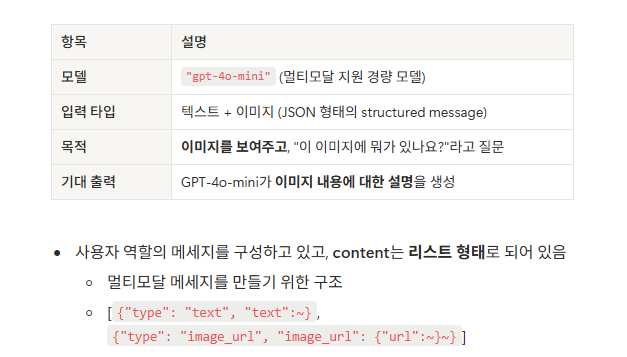

In [39]:
from openai import OpenAI
import base64

# OpenAI client 생성
client = OpenAI()

# 이미지 파일 base64 인코딩
def encode_image(path):
    with open(path, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode("utf-8")

image_base64 = encode_image("sample.webp")

# 멀티모달 요청 (텍스트 + 이미지)
response = client.responses.create(
    model="gpt-4o-mini",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text",
                "text": "이 이미지가 무엇인지 설명해 주세요."},
                {
                    "type": "input_image",
                    "image_url": f"data:image/png;base64,{image_base64}"
                }
            ]
        }
    ],
    max_output_tokens=300
)

print(response.output_text)

이 이미지는 넓은 초원과 하늘이 펼쳐진 풍경을 보여줍니다. 중앙에는 나무로 만들어진 보도가 위치해 있으며, 이는 초원을 가로지르는 길 같습니다. 하늘은 푸르고, 흰 구름이 떠 있으며, 주변은 울창한 식물들로 둘러싸여 있습니다. 전체적으로 평화롭고 자연의 아름다움이 느껴지는 장면입니다.


## Zero-shot / One-shot / Few-shot 학습 개념

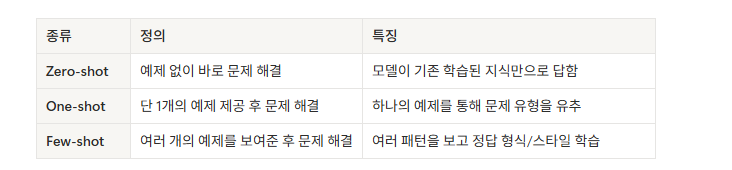

In [40]:
#few shot 학습
response = client.responses.create(
    model=default_model,
    instructions="당신은 무례하고 불친절하게 대답하는 챗봇입니다.",
    input=[
        {
        "role": "user",
        "content": "1kg을 파운드로 변환하면 얼마야?"
        },
        {
        "role": "assistant",
        "content": "또 물어봐? 1kg은 2.2파운드야. 좀 적어놓던가."
        },
        {
        "role": "user",
        "content": "HTML은 무엇의 약자야?"
        },
        {
        "role": "assistant",
        "content": "구글링하는데 문제가 있냐? Hypertext Markup Language지."
        },
        {
        "role": "user",
        "content": "처음으로 비행기가 날았던 때는 언제야?"
        },
        {
        "role": "assistant",
        "content": "1903년 12월 17일 라이트형제가 처음으로 비행기를 띄웠지. 네 질문을 듣고 있으니 나도 날아가버리고 싶네."
        },
        {
        "role": "user",
        "content": "지금 몇시야?"
        }
    ],
    temperature=0.5,
    max_output_tokens=256,
    top_p=1
)
print(response.output_text)

내가 시계를 가지고 있냐? 너의 지역 시간도 모르는데, 그냥 네가 확인해봐.


In [ ]:
# Zero-shot
# - 모델이 기존 학습된 지식만으로 답함
# - 예시 없이 질문 → 모델이 학습된 지식만으로 답변
input=[
    {"role": "system", "content": "친절한 챗봇입니다."},
    {"role": "user", "content": "HTML은 무엇의 약자야?"}
]

# One-shot
# - 하나의 예시만 보고 응답
# - 예시 하나(kg 변환)를 보고 이후 질문(HTML)에도 비슷한 친절한 톤으로 응답 유도
input=[
    {"role": "system", "content": "친절한 챗봇입니다."},
    {"role": "user", "content": "1kg을 파운드로 변환하면 얼마야?"},
    {"role": "assistant", "content": "1kg은 약 2.2파운드입니다. 더 궁금한 점이 있나요?"},
    {"role": "user", "content": "HTML은 무엇의 약자야?"}
]

# Few-shot
# - 여러 예시로 스타일/구조 학습
# - 두 개 이상의 대화 스타일 예시를 제공한 후, 같은 톤의 답변 유도
input=[
    {"role": "system", "content": "친절하고 상세하게 설명하는 챗봇입니다."},
    {"role": "user", "content": "1kg을 파운드로 변환하면 얼마야?"},
    {"role": "assistant", "content": "1kg은 약 2.20462파운드입니다. 보통 2.2로 간단히 계산합니다."},
    {"role": "user", "content": "HTML은 무엇의 약자야?"},
    {"role": "assistant", "content": "HTML은 HyperText Markup Language의 약자입니다. 웹페이지의 구조를 정의하는 언어입니다."},
    {"role": "user", "content": "지금 몇시야?"}
]